In [ ]:
# Car Price Prediction with Machine Learning

## 1. Project Overview
#This project builds a machine learning model to predict used car selling prices based on vehicle characteristics.

In [ ]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

print("Environment setup successful!")


Environment setup successful!


In [227]:
df=pd.read_csv("../Datasets/cardekho_dataset.csv")
print(df)

       Unnamed: 0         car_name     brand     model  vehicle_age  \
0               0      Maruti Alto    Maruti      Alto            9   
1               1    Hyundai Grand   Hyundai     Grand            5   
2               2      Hyundai i20   Hyundai       i20           11   
3               3      Maruti Alto    Maruti      Alto            9   
4               4    Ford Ecosport      Ford  Ecosport            6   
...           ...              ...       ...       ...          ...   
15406       19537      Hyundai i10   Hyundai       i10            9   
15407       19540    Maruti Ertiga    Maruti    Ertiga            2   
15408       19541      Skoda Rapid     Skoda     Rapid            6   
15409       19542  Mahindra XUV500  Mahindra    XUV500            5   
15410       19543       Honda City     Honda      City            2   

       km_driven seller_type fuel_type transmission_type  mileage  engine  \
0         120000  Individual    Petrol            Manual    19.70     

In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


In [229]:
df.head(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


In [230]:
df.shape

(15411, 14)

In [231]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='str')

In [232]:
df.dtypes

Unnamed: 0             int64
car_name                 str
brand                    str
model                    str
vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [233]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [234]:
df.describe(include="object")

C:\Users\PREETHIKA\AppData\Local\Temp\ipykernel_39536\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


In [235]:
df["car_name"].unique()

<StringArray>
[          'Maruti Alto',         'Hyundai Grand',           'Hyundai i20',
         'Ford Ecosport',        'Maruti Wagon R',           'Hyundai i10',
         'Hyundai Venue',          'Maruti Swift',         'Hyundai Verna',
        'Renault Duster',
 ...
      'Mahindra Alturas',           'Tata Altroz',              'Lexus NX',
          'Kia Carnival',        'Mercedes-AMG C',              'Lexus RX',
     'Rolls-Royce Ghost', 'Maserati Quattroporte',             'Isuzu MUX',
          'Force Gurkha']
Length: 121, dtype: str

In [236]:
df["fuel_type"].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

In [237]:
df["seller_type"].unique()

<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

In [238]:
df["brand"].unique()

<StringArray>
[       'Maruti',       'Hyundai',          'Ford',       'Renault',
          'Mini', 'Mercedes-Benz',        'Toyota',    'Volkswagen',
         'Honda',      'Mahindra',        'Datsun',          'Tata',
           'Kia',           'BMW',          'Audi',    'Land Rover',
        'Jaguar',            'MG',         'Isuzu',       'Porsche',
         'Skoda',         'Volvo',         'Lexus',          'Jeep',
      'Maserati',       'Bentley',        'Nissan',         'ISUZU',
       'Ferrari',  'Mercedes-AMG',   'Rolls-Royce',         'Force']
Length: 32, dtype: str

In [239]:
df["model"].unique()

<StringArray>
[        'Alto',        'Grand',          'i20',     'Ecosport',
      'Wagon R',          'i10',        'Venue',        'Swift',
        'Verna',       'Duster',
 ...
     'Panamera',      'Alturas',       'Altroz',           'NX',
     'Carnival',            'C',           'RX',        'Ghost',
 'Quattroporte',       'Gurkha']
Length: 120, dtype: str

In [240]:
df["transmission_type"].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [241]:
df["engine"].unique()

array([ 796, 1197,  998, 1498, 1582, 1461, 1998, 1248, 2143, 2494, 1598,
       1497, 2523, 2982,  999, 1199, 1086, 2179, 1396, 1198, 1590, 1997,
       1493, 1120, 1196, 1186, 1061,  799, 1796, 2993, 1298, 3198, 1995,
       1373, 1591, 1968, 1399, 1047, 1353, 2755, 1395, 2498, 1999, 2953,
       2393, 2967, 2998, 2995, 1956, 1462, 1799, 2499, 1451, 1194, 1798,
       2694, 1496, 1969, 2487, 3604, 1499, 2987, 1599, 2354, 1950, 2148,
       4134, 2400, 1984, 2979, 2609, 2092, 5998, 1330, 2956, 3598, 2362,
        793, 1368, 3597, 1991, 5461, 1343, 2497, 4367, 1797, 3498, 2698,
       1896, 2999, 3855, 4806, 1985, 2771, 2157, 3628, 2198, 2996, 2199,
       4395, 3456, 4663, 2773, 6592, 2495, 1781, 2997, 1597, 2596, 4163])

In [242]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
15406    False
15407    False
15408    False
15409    False
15410    False
Length: 15411, dtype: bool

In [243]:
df["km_driven"].max()
 

np.int64(3800000)

In [244]:
df["km_driven"].min()

np.int64(100)

In [245]:
df["max_power"].min()

np.float64(38.4)

In [246]:
df["max_power"].min()

np.float64(38.4)

In [247]:
df["vehicle_age"].max()

np.int64(29)

In [248]:
df["vehicle_age"].min()

np.int64(0)

In [249]:
df["engine"].max()

np.int64(6592)

In [250]:
df["engine"].min()

np.int64(793)

In [251]:
df["selling_price"].max()

np.int64(39500000)

In [252]:
df["selling_price"].min()

np.int64(40000)

<Axes: xlabel='selling_price', ylabel='Count'>

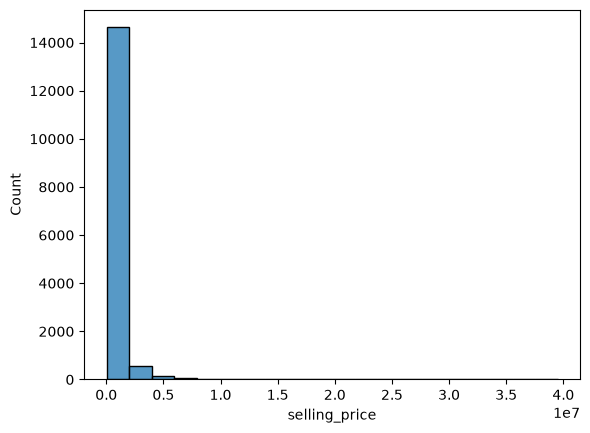

In [253]:
sns.histplot(df["selling_price"],bins=20)

<Axes: xlabel='selling_price', ylabel='vehicle_age'>

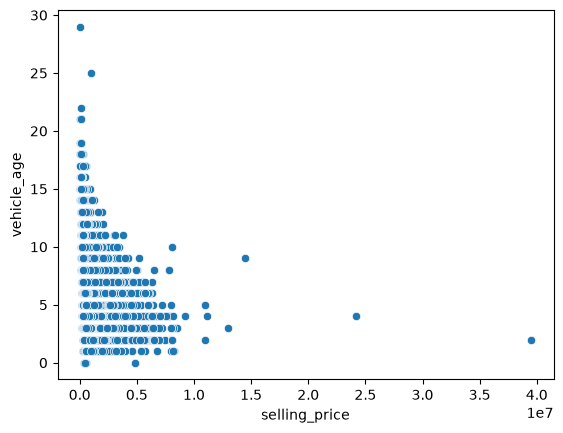

In [254]:
sns.scatterplot(x=df["selling_price"],y=df["vehicle_age"])

<Axes: xlabel='selling_price', ylabel='km_driven'>

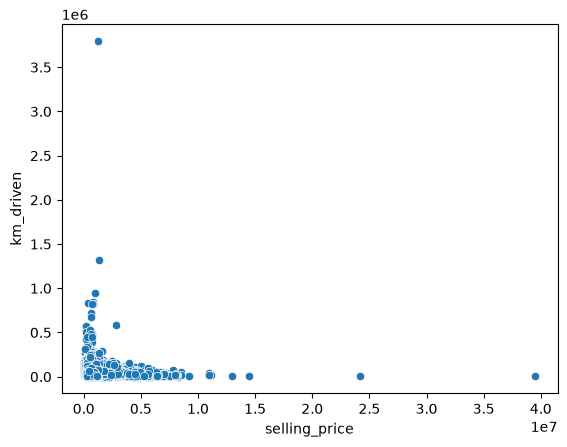

In [255]:
sns.scatterplot(x=df["selling_price"],y=df["km_driven"])

<Axes: xlabel='count', ylabel='fuel_type'>

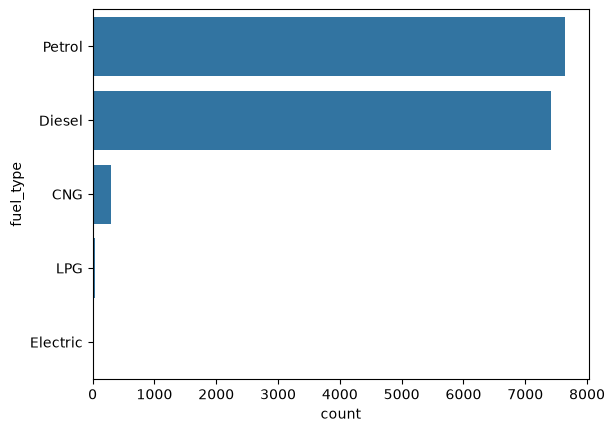

In [256]:
sns.countplot(df["fuel_type"])

In [257]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,15411.0,9811.857699,5643.418542,0.0,4906.5,9872.00,14668.5,19543.00
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


In [258]:
df["fuel_type"].value_counts()

fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

In [259]:
df["transmission_type"].value_counts()

transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

In [260]:
df["seller_type"].value_counts()

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

In [261]:
df["brand"].value_counts()

brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Jaguar             59
Land Rover         51
Jeep               41
Kia                32
Porsche            21
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus              10
Isuzu               8
Bentley             3
Maserati            2
ISUZU               2
Ferrari             1
Mercedes-AMG        1
Rolls-Royce         1
Force               1
Name: count, dtype: int64

In [262]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].unique())


car_name
<StringArray>
[          'Maruti Alto',         'Hyundai Grand',           'Hyundai i20',
         'Ford Ecosport',        'Maruti Wagon R',           'Hyundai i10',
         'Hyundai Venue',          'Maruti Swift',         'Hyundai Verna',
        'Renault Duster',
 ...
      'Mahindra Alturas',           'Tata Altroz',              'Lexus NX',
          'Kia Carnival',        'Mercedes-AMG C',              'Lexus RX',
     'Rolls-Royce Ghost', 'Maserati Quattroporte',             'Isuzu MUX',
          'Force Gurkha']
Length: 121, dtype: str

brand
<StringArray>
[       'Maruti',       'Hyundai',          'Ford',       'Renault',
          'Mini', 'Mercedes-Benz',        'Toyota',    'Volkswagen',
         'Honda',      'Mahindra',        'Datsun',          'Tata',
           'Kia',           'BMW',          'Audi',    'Land Rover',
        'Jaguar',            'MG',         'Isuzu',       'Porsche',
         'Skoda',         'Volvo',         'Lexus',          'Jeep',
    

C:\Users\PREETHIKA\AppData\Local\Temp\ipykernel_39536\88652429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [263]:
X = df[["vehicle_age", "km_driven", "fuel_type", "transmission_type", "seller_type", "brand", "model", "engine"]]
Y = df["selling_price"]

In [264]:
X.shape

(15411, 8)

In [265]:
Y.shape

(15411,)

In [266]:
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(exclude="object").columns

C:\Users\PREETHIKA\AppData\Local\Temp\ipykernel_39536\49708069.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [267]:
print("Categorical Features:",categorical_features)
print("Numerical Features:",numerical_features)

Categorical Features: Index(['fuel_type', 'transmission_type', 'seller_type', 'brand', 'model'], dtype='str')
Numerical Features: Index(['vehicle_age', 'km_driven', 'engine'], dtype='str')


In [268]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [269]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [270]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [271]:
from sklearn.linear_model import LinearRegression

In [272]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [273]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['vehicle_age','km_driven','fuel_type',...,'brand','model','engine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [274]:
y_pred_linear = linear_model.predict(X_test)

In [275]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [276]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

In [277]:
print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 182789.00670607516
RMSE: 396149.0087837183
R²  : 0.7915278515709221


In [278]:
from sklearn.ensemble import RandomForestRegressor

In [279]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [280]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['vehicle_age','km_driven','fuel_type',...,'brand','model','engine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

In [281]:
y_pred_rf = rf_model.predict(X_test)

In [282]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

In [283]:
print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 101217.3846069642
RMSE: 215715.28650778913
R²  : 0.9381851614619051


In [284]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R2": [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,182789.006706,396149.008784,0.791528
1,Random Forest,101217.384607,215715.286508,0.938185


In [285]:
best_predictions = y_pred_rf

In [286]:
best_predictions = y_pred_linear

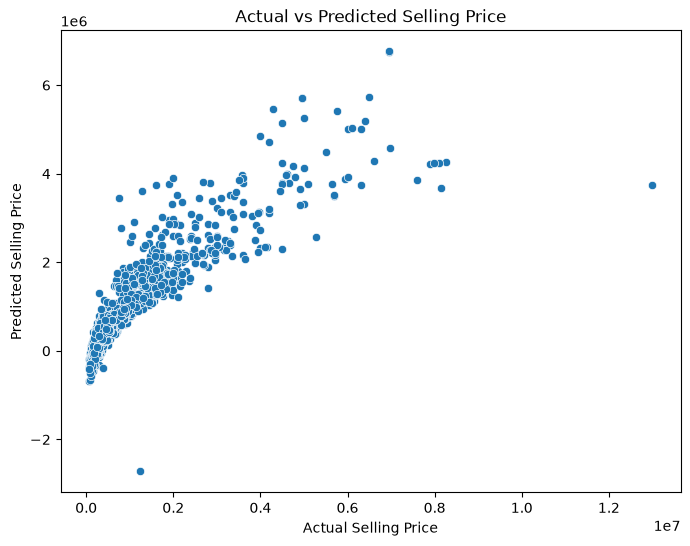

In [287]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=best_predictions)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [288]:
rf = rf_model.named_steps["model"]

In [289]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

In [290]:
importances = rf.feature_importances_

In [291]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
2,num__engine,0.407676
1,num__km_driven,0.116861
0,num__vehicle_age,0.106219
8,cat__transmission_type_Automatic,0.070389
9,cat__transmission_type_Manual,0.062559
17,cat__brand_Ferrari,0.061572
93,cat__model_GTC4Lusso,0.053700
38,cat__brand_Rolls-Royce,0.010528
95,cat__model_Ghost,0.007580
30,cat__brand_Mahindra,0.005907


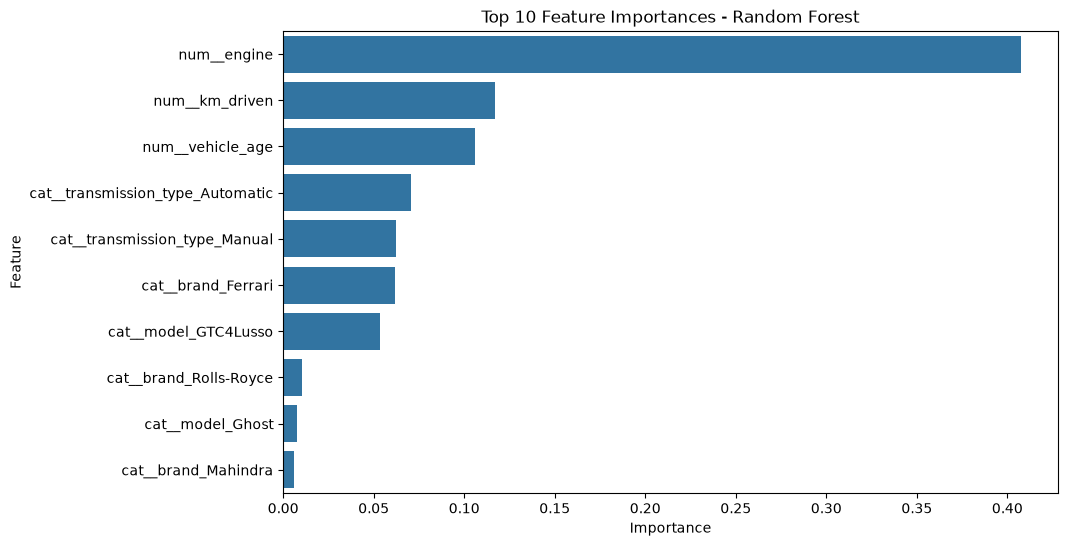

In [292]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [293]:
residuals = y_test - y_pred_rf

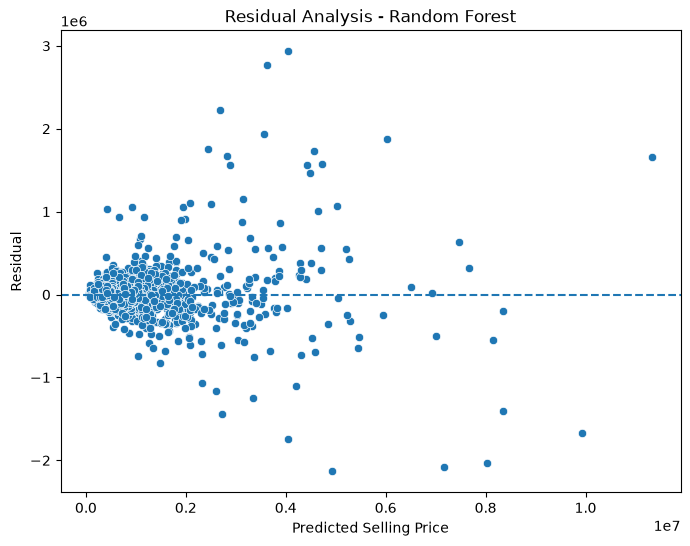

In [294]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Analysis - Random Forest")
plt.show()

In [295]:
error_analysis = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf,
    "Error": residuals,
    "Absolute_Error": abs(residuals)
}).sort_values("Absolute_Error", ascending=False)

error_analysis.head(10)

,Actual,Predicted,Error,Absolute_Error
9975,6975000,4.043370e+06,2.931630e+06,2.931630e+06
14544,6400000,3.628840e+06,2.771160e+06,2.771160e+06
14725,4900000,2.675690e+06,2.224310e+06,2.224310e+06
3710,2790000,4.924900e+06,-2.134900e+06,2.134900e+06
9362,5100000,7.174802e+06,-2.074802e+06,2.074802e+06
9545,6000000,8.031941e+06,-2.031941e+06,2.031941e+06
7518,5499000,3.557165e+06,1.941835e+06,1.941835e+06
351,7900000,6.026325e+06,1.873675e+06,1.873675e+06
4304,4200000,2.444470e+06,1.755530e+06,1.755530e+06
12564,2300000,4.043422e+06,-1.743422e+06,1.743422e+06


In [297]:
import joblib

In [300]:
import os

os.makedirs("Models", exist_ok=True)

In [307]:
joblib.dump(rf_model, "../Models/car_price_prediction.pkl")

['../Models/car_price_prediction.pkl']

In [302]:
print("Model saved successfully!")

Model saved successfully!


In [303]:
import os

print(os.path.exists("Models/car_price_prediction.pkl"))

True


In [308]:
loaded_model = joblib.load("../Models/car_price_prediction.pkl")

In [305]:
test_predictions = loaded_model.predict(X_test)

In [306]:
np.allclose(y_pred_rf, test_predictions)

True

In [ ]:
## Final Model Selection

#Random Forest Regression performed better than Linear Regression across all evaluation metrics.

#The Random Forest model achieved an R² score of approximately 0.938, with lower MAE and RMSE than Linear Regression.

#Therefore, Random Forest was selected as the final model for car price prediction.

In [ ]:
## Conclusion

#The project successfully developed a machine learning model for predicting used car selling prices.

#Exploratory analysis showed that vehicle characteristics such as engine capacity, kilometers driven, and vehicle age were important factors in price prediction.

#Among the evaluated models, Random Forest Regression provided the best performance with an R² score of approximately 0.938.

#The trained Random Forest pipeline was saved for future predictions.